In [ ]:
import sys
from pathlib import Path
# Ensure repository root is on sys.path so local modules import
sys.path.insert(0, str(Path.cwd().parents[0]))
# Ensure local rompy package is importable
sys.path.insert(0, '/home/qubit/Documents')

In [42]:
import rompy as rp
import numpy as np
import matplotlib.pyplot as plt
from surrogw.dataset.loader import DataLoader

plt.rcParams.update({'figure.max_open_warning': 0})

In [47]:
# Load training data (expects training_data.hdf5 in the notebook folder)
data = DataLoader(filename='training_data.hdf5')
print('Loaded data: n_waveforms=', data.n_waveforms, 'n_amp_nodes=', data.n_amp_nodes)

Loaded data: n_waveforms= 3600 n_amp_nodes= 200


In [48]:
# Build rompy Integration using the sparse amplitude frequency grid
freq_nodes = data.sparse_freq_amp
weights = np.ones_like(freq_nodes)  # simple trapezoidal-like weights if exact weights not needed
integration = rp.Integration(nodes=freq_nodes, weights=weights)

# Construct reduced basis with rompy and run the greedy algorithm
rb = rp.ReducedBasis(integration)
# rompy expects training_space shape (n_samples, n_quadrature_nodes)
# Our A_mat is (n_quadrature_nodes, n_snapshots) so transpose it
training_space = np.asarray(data.A_mat).T
rb.make(training_space=training_space, index_seed=0, tol=1e-8, verbose=True, timer=True)
print('Reduced basis built. Number of modes =', rb.basis.shape[1])

Step      Error
1:   4.084984748273404
2:   0.018223897450525328
3:   0.002172249800392656
4:   0.0006479906134915225
5:   0.00019528248058442443
6:   0.00010348198702514466
7:   4.830370210084922e-05
8:   3.4736562153359074e-05
9:   2.1834658965325104e-05
10:   9.982199881353182e-06
11:   7.117633910258547e-06
12:   6.5368330974813205e-06
13:   5.772888311383895e-06
14:   4.605028145476808e-06
15:   4.3723957787733525e-06
16:   4.274870069043146e-06
17:   2.6289992338668355e-06
18:   2.2616304686806643e-06
19:   2.0843638290912736e-06
20:   1.8615833905499812e-06
21:   1.6803093103590072e-06
>>> Warning(Index already selected): Exiting greedy algorithm.
('\nElapsed time =', 0.11876749992370605)
Reduced basis built. Number of modes = 200


Step      Error
1:   0.9998088418889923
2:   0.03308539424774981
3:   0.011168856326852605


4:   0.005395163395839231
5:   0.0022142016235678907
6:   0.001255017043256923
7:   0.0005781240805864396
8:   0.00032644250081403925
9:   0.00022379262446725612
10:   0.00012114972565957505
11:   9.333934161592783e-05
12:   6.142241032458529e-05
13:   3.477253542238934e-05
14:   1.9033655797140447e-05
15:   1.1003757417915594e-05
16:   8.505325709506906e-06
17:   6.249288716952961e-06
18:   4.385026003639325e-06
19:   3.2232846294277806e-06
20:   3.032439130468134e-06
21:   1.7724132937990689e-06
22:   1.6925108172749503e-06
23:   1.3826385478754588e-06
24:   1.1555109907801508e-06
25:   1.0053121296538237e-06
26:   7.54785239420741e-07
27:   6.940999066618048e-07
28:   6.085912767073154e-07
29:   5.400790610288198e-07
30:   5.295127420978929e-07
31:   5.135841875114622e-07
32:   4.828953331648123e-07
33:   4.807896704095427e-07
34:   4.5866104336766966e-07
35:   4.534795664534741e-07
36:   4.4048304581600917e-07
37:   4.316347677058019e-07
38:   4.28384484552069e-07
39:   4.105048654

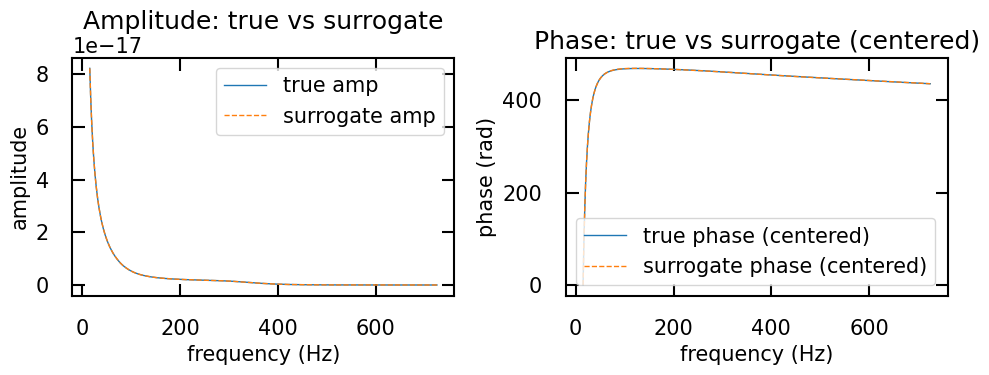

In [49]:
import random
import scipy.interpolate as si

# Helper: trapezoidal weights for arbitrary nodes
def trapezoidal_weights(x):
    x = np.asarray(x)
    dx = np.diff(x)
    w = np.empty_like(x)
    if len(x) == 1:
        return np.array([1.0])
    w[0] = dx[0]/2.0
    w[-1] = dx[-1]/2.0
    if len(x) > 2:
        w[1:-1] = 0.5*(dx[:-1] + dx[1:])
    return w

# --- Build RB + EIM for amplitude ---
freq_amp = data.sparse_freq_amp
w_amp = trapezoidal_weights(freq_amp)
int_amp = rp.Integration(nodes=freq_amp, weights=w_amp)
training_amp = np.asarray(data.A_mat).T  # shape (n_snapshots, n_freqs)
rb_amp = rp.ReducedBasis(int_amp)
rb_amp.make(training_space=training_amp, index_seed=0, tol=1e-8, verbose=True, timer=True)
eim_amp = rp.EmpiricalInterpolant(rb_amp.basis, verbose=True)
print('Amplitude RB modes =', rb_amp.basis.shape, 'EIM nodes =', len(eim_amp.indices))

# --- Build RB + EIM for phase (center each waveform by its initial phase) ---
freq_phase = data.sparse_freq_phase
w_phase = trapezoidal_weights(freq_phase)
int_phase = rp.Integration(nodes=freq_phase, weights=w_phase)
training_phase = np.asarray(data.Phi_mat).T
# Remove each waveform's initial phase to make phases smooth across params
training_phase_centered = training_phase - training_phase[:,0][:,None]
rb_phase = rp.ReducedBasis(int_phase)
rb_phase.make(training_space=training_phase_centered, index_seed=0, tol=1e-8, verbose=True, timer=True)
eim_phase = rp.EmpiricalInterpolant(rb_phase.basis, verbose=True)
print('Phase RB modes =', rb_phase.basis.shape, 'EIM nodes =', len(eim_phase.indices))

# --- Build parameter-space interpolants for EIM node values and amp norms ---
q_unique = np.unique(data.param_grid_q)
chi_unique = np.unique(data.param_grid_chi)
grid_shape = data.param_grid_q.shape
n_snapshots = training_amp.shape[0]

# amplitude: collect node values across training set for each EIM index
amp_node_vals = training_amp[:, eim_amp.indices]  # (n_snapshots, n_eim)
phase_node_vals = training_phase_centered[:, eim_phase.indices]

# reshape into (n_chi, n_q) grids and build RectBivariateSpline for each node
amp_node_interps = []
for k in range(amp_node_vals.shape[1]):
    z = amp_node_vals[:, k].reshape(grid_shape)
    amp_node_interps.append(si.RectBivariateSpline(chi_unique, q_unique, z))

phase_node_interps = []
for k in range(phase_node_vals.shape[1]):
    z = phase_node_vals[:, k].reshape(grid_shape)
    phase_node_interps.append(si.RectBivariateSpline(chi_unique, q_unique, z))

# amplitude norm interpolant (amp_norms stored per snapshot)
amp_norms_grid = np.asarray(data.amp_norms).reshape(grid_shape)
amp_norm_interp = si.RectBivariateSpline(chi_unique, q_unique, amp_norms_grid)

# --- Choose a random training sample to validate surrogate reconstruction ---
rand_idx = random.randrange(n_snapshots)
q0 = float(data.q[rand_idx])
chi0 = float(data.chi[rand_idx])
print('Validating on training sample index', rand_idx, 'q=', q0, 'chi=', chi0)

# Evaluate node interpolants at (chi0, q0)
amp_nodes_pred = np.array([interp(chi0, q0)[0,0] for interp in amp_node_interps])
phase_nodes_pred = np.array([interp(chi0, q0)[0,0] for interp in phase_node_interps])
amp_norm_pred = float(amp_norm_interp(chi0, q0)[0,0])

# Reconstruct full fields from EIM matrix B (B shape (Nbasis, Nquads))
amp_rec = amp_nodes_pred.dot(eim_amp.B)
phase_rec = phase_nodes_pred.dot(eim_phase.B)

# Scale amplitude back using amp_norm
amp_rec_scaled = amp_rec * amp_norm_pred
# retrieve true data for comparison (true amplitude stored normalized in A_mat)
true_amp = np.asarray(data.A_mat)[:, rand_idx] * data.amp_norms[rand_idx]
true_phase = np.asarray(data.Phi_mat)[:, rand_idx]
# center true phase the same way we trained phase RB
true_phase_centered = true_phase - true_phase[0]
# add back initial phase to reconstructed phase for direct compare
phase_rec_full = phase_rec + true_phase[0]

# --- Metrics ---
amp_err = np.linalg.norm(true_amp - amp_rec_scaled) / np.linalg.norm(true_amp)
phase_err = np.linalg.norm(true_phase_centered - phase_rec) / max(1e-12, np.linalg.norm(true_phase_centered))
print(f'Relative L2 error (amp) = {amp_err:.3e}, (phase) = {phase_err:.3e}')

# --- Plots ---
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(freq_amp, true_amp, label='true amp')
plt.plot(freq_amp, amp_rec_scaled, '--', label='surrogate amp')
plt.xlabel('frequency (Hz)')
plt.ylabel('amplitude')
plt.title('Amplitude: true vs surrogate')
plt.legend()

plt.subplot(1,2,2)
plt.plot(freq_phase, true_phase_centered, label='true phase (centered)')
plt.plot(freq_phase, phase_rec, '--', label='surrogate phase (centered)')
plt.xlabel('frequency (Hz)')
plt.ylabel('phase (rad)')
plt.title('Phase: true vs surrogate (centered)')
plt.legend()
plt.tight_layout()
plt.show()